In [1]:
# ==========================================================
# AI-Driven Phishing Email Detection Using NLP
# Author : Harshvardhan Natu
# GitHub : https://github.com/harshu1924
# ==========================================================

print("🚀 Project Started Successfully!")

🚀 Project Started Successfully!


In [2]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display plots inside notebook
%matplotlib inline

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [3]:
# ================================
# Load Dataset
# ================================

df = pd.read_csv("../dataset/Phishing_Email.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [5]:
# ====================================
# Dataset Shape
# ====================================

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 18650
Number of Columns : 3


In [6]:
# ====================================
# Dataset Information
# ====================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18650 entries, 0 to 18649
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  18650 non-null  int64
 1   Email Text  18634 non-null  str  
 2   Email Type  18650 non-null  str  
dtypes: int64(1), str(2)
memory usage: 49.7 MB


In [7]:
# ====================================
# Column Names
# ====================================

print(df.columns.tolist())

['Unnamed: 0', 'Email Text', 'Email Type']


In [8]:
# ====================================
# Missing Values
# ====================================

df.isnull().sum()

Unnamed: 0     0
Email Text    16
Email Type     0
dtype: int64

In [9]:
# ====================================
# Duplicate Rows
# ====================================

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [10]:
# ====================================
# Email Categories
# ====================================

df["Email Type"].value_counts()

Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

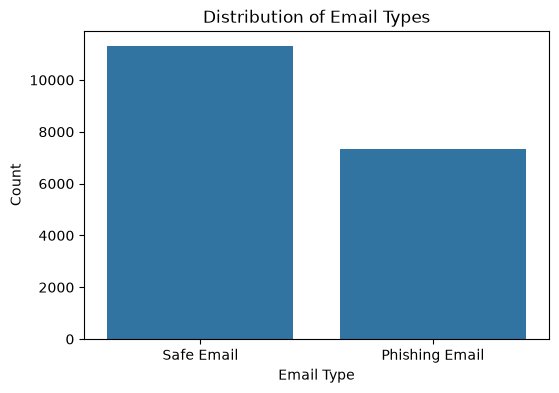

In [11]:
# ====================================
# Class Distribution
# ====================================

plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Email Type")

plt.title("Distribution of Email Types")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

In [12]:
# ====================================
# Basic Statistics
# ====================================

df.describe(include="all")

,Unnamed: 0,Email Text,Email Type
count,18650.000000,18634,18650
unique,NaN,17537,2
top,NaN,empty,Safe Email
freq,NaN,533,11322
mean,9325.154477,NaN,NaN
std,5384.327293,NaN,NaN
min,0.000000,NaN,NaN
25%,4662.250000,NaN,NaN
50%,9325.500000,NaN,NaN
75%,13987.750000,NaN,NaN


In [13]:
# ==========================================================
# Create a Working Copy
# ==========================================================

data = df.copy()

print("Working copy created successfully!")

Working copy created successfully!


In [14]:
# ==========================================================
# Remove Unnecessary Column
# ==========================================================

data.drop(columns=["Unnamed: 0"], inplace=True)

print("Column removed successfully!")

data.head()

Column removed successfully!


,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [15]:
# ==========================================================
# Remove Missing Values
# ==========================================================

print("Missing values before cleaning:")
print(data.isnull().sum())

data.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

print(f"\nDataset Shape After Cleaning: {data.shape}")


Missing values before cleaning:
Email Text    16
Email Type     0
dtype: int64

Missing values after cleaning:
Email Text    0
Email Type    0
dtype: int64

Dataset Shape After Cleaning: (18634, 2)


In [16]:
# ==========================================================
# Rename Columns
# ==========================================================

data.rename(columns={
    "Email Text": "text",
    "Email Type": "label"
}, inplace=True)

print("Columns renamed successfully!")

print(data.columns)

Columns renamed successfully!
Index(['text', 'label'], dtype='str')


In [17]:
data.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [18]:
# ==========================================================
# Encode Labels
# ==========================================================

# Convert labels into numerical values
data["label"] = data["label"].map({
    "Safe Email": 0,
    "Phishing Email": 1
})

print("Labels encoded successfully!\n")

print(data["label"].value_counts())

Labels encoded successfully!

label
0    11322
1     7312
Name: count, dtype: int64


In [19]:
# ==========================================================
# Verify Cleaned Dataset
# ==========================================================

data.head()

,text,label
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


In [20]:
# ==========================================================
# Final Dataset Shape
# ==========================================================

print(data.shape)

(18634, 2)


In [21]:
# ==========================================================
# Import NLP Libraries
# ==========================================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download required NLTK resources (only needed once)
nltk.download("punkt")
nltk.download("stopwords")

print("NLP Libraries Loaded Successfully!")

NLP Libraries Loaded Successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Harshvardhan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Harshvardhan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
# ==========================================================
# Initialize NLP Objects
# ==========================================================

stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

print("Stemmer and Stopwords Initialized!")
print(f"Total Stopwords: {len(stop_words)}")

Stemmer and Stopwords Initialized!
Total Stopwords: 198


In [23]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove email addresses
    text = re.sub(r"\S+@\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [24]:
# ==========================================================
# Test Cleaning Function
# ==========================================================

sample = data["text"].iloc[0]

print("Original Email:\n")
print(sample)

print("\n" + "="*60)

print("\nCleaned Email:\n")
print(clean_text(sample))

Original Email:

re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure that it is fair to attribute this to " sons " being " treated like senior relatives " . for one thing , we do n't normally use ' brother ' in this way any more than we do 'd aughter ' , and it is hard to imagine a natural class comprising senior relatives and 's on ' but excluding ' brother ' . for another , there seem to me to be differences here . if i am not imagining a distinction that is not there , it seems to me that the senior relative terms are used in a wider variety of contexts , e . g . , calling out from a distance to get someone 's attention , and hence at the beginning of an utterance , whereas 's on ' seems more natural in utterances like ' yes , son ' , ' hand me that , son ' than in ones like ' son ! ' or ' son , help me ! ' ( although perhaps these latter o

In [25]:
# ==========================================================
# Clean Entire Dataset
# ==========================================================

data["clean_text"] = data["text"].apply(clean_text)

print("Text Cleaning Completed Successfully!")

data[["text", "clean_text"]].head()

Text Cleaning Completed Successfully!


,text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",re disc uniformitarianism re sex lang dick hud...
1,the other side of * galicismos * * galicismo *...,the other side of galicismos galicismo is a sp...
2,re : equistar deal tickets are you still avail...,re equistar deal tickets are you still availab...
3,\nHello I am your hot lil horny toy.\n I am...,hello i am your hot lil horny toy i am the one...
4,software at incredibly low prices ( 86 % lower...,software at incredibly low prices lower draper...


In [26]:
# ==========================================================
# Before vs After Cleaning
# ==========================================================

print("Original Email\n")
print(data["text"].iloc[3])

print("\n" + "="*80)

print("\nCleaned Email\n")
print(data["clean_text"].iloc[3])

Original Email


Hello I am your hot lil horny toy.
    I am the one you dream About,
    I am a very open minded person,
    Love to talk about and any subject.
    Fantasy is my way of life, 
    Ultimate in sex play.     Ummmmmmmmmmmmmm
     I am Wet and ready for you.     It is not your looks but your imagination that matters most,
     With My sexy voice I can make your dream come true...
  
     Hurry Up! call me let me Cummmmm for you..........................
TOLL-FREE:             1-877-451-TEEN (1-877-451-8336)For phone billing:     1-900-993-2582
-- 
_______________________________________________
Sign-up for your own FREE Personalized E-mail at Mail.com
http://www.mail.com/?sr=signup


Cleaned Email

hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most

In [27]:
# ==========================================================
# NLP Processing Function
# ==========================================================

def preprocess_text(text):

    # Tokenize
    words = word_tokenize(text)

    processed_words = []

    for word in words:

        # Keep only alphabetic words
        if word.isalpha():

            # Remove stopwords
            if word not in stop_words:

                # Apply stemming
                stemmed_word = stemmer.stem(word)

                processed_words.append(stemmed_word)

    return " ".join(processed_words)

In [28]:
# ==========================================================
# Test NLP Processing
# ==========================================================

sample = data["clean_text"].iloc[0]

print("Clean Text:\n")
print(sample)

print("\n" + "="*70)

print("\nProcessed Text:\n")
print(preprocess_text(sample))

Clean Text:

re disc uniformitarianism re sex lang dick hudson s observations on us use of s on but not d aughter as a vocative are very thoughtprovoking but i am not sure that it is fair to attribute this to sons being treated like senior relatives for one thing we do nt normally use brother in this way any more than we do d aughter and it is hard to imagine a natural class comprising senior relatives and s on but excluding brother for another there seem to me to be differences here if i am not imagining a distinction that is not there it seems to me that the senior relative terms are used in a wider variety of contexts e g calling out from a distance to get someone s attention and hence at the beginning of an utterance whereas s on seems more natural in utterances like yes son hand me that son than in ones like son or son help me although perhaps these latter ones are not completely impossible alexis mr


Processed Text:

disc uniformitarian sex lang dick hudson observ us use aughter

In [29]:
# ==========================================================
# Apply NLP Processing
# ==========================================================

data["processed_text"] = data["clean_text"].apply(preprocess_text)

print("NLP Processing Completed Successfully!")

data[["clean_text", "processed_text"]].head()

NLP Processing Completed Successfully!


,clean_text,processed_text
0,re disc uniformitarianism re sex lang dick hud...,disc uniformitarian sex lang dick hudson obser...
1,the other side of galicismos galicismo is a sp...,side galicismo galicismo spanish term name imp...
2,re equistar deal tickets are you still availab...,equistar deal ticket still avail assist robert...
3,hello i am your hot lil horny toy i am the one...,hello hot lil horni toy one dream open mind pe...
4,software at incredibly low prices lower draper...,softwar incred low price lower draperi sevente...


In [30]:
# ==========================================================
# Compare Text Transformations
# ==========================================================

index = 3

print("ORIGINAL EMAIL\n")
print(data.loc[index, "text"])

print("\n" + "="*80)

print("\nCLEANED EMAIL\n")
print(data.loc[index, "clean_text"])

print("\n" + "="*80)

print("\nPROCESSED EMAIL\n")
print(data.loc[index, "processed_text"])

ORIGINAL EMAIL


Hello I am your hot lil horny toy.
    I am the one you dream About,
    I am a very open minded person,
    Love to talk about and any subject.
    Fantasy is my way of life, 
    Ultimate in sex play.     Ummmmmmmmmmmmmm
     I am Wet and ready for you.     It is not your looks but your imagination that matters most,
     With My sexy voice I can make your dream come true...
  
     Hurry Up! call me let me Cummmmm for you..........................
TOLL-FREE:             1-877-451-TEEN (1-877-451-8336)For phone billing:     1-900-993-2582
-- 
_______________________________________________
Sign-up for your own FREE Personalized E-mail at Mail.com
http://www.mail.com/?sr=signup


CLEANED EMAIL

hello i am your hot lil horny toy i am the one you dream about i am a very open minded person love to talk about and any subject fantasy is my way of life ultimate in sex play ummmmmmmmmmmmmm i am wet and ready for you it is not your looks but your imagination that matters most

In [31]:
# ==========================================================
# Check Empty Processed Text
# ==========================================================

empty_rows = (data["processed_text"].str.len() == 0).sum()

print(f"Empty Processed Emails: {empty_rows}")

Empty Processed Emails: 6


In [32]:
# ==========================================================
# Remove Empty Rows
# ==========================================================

data = data[data["processed_text"].str.strip() != ""]

print("Dataset Shape After NLP Processing:")
print(data.shape)

Dataset Shape After NLP Processing:
(18628, 4)


In [33]:
# ==========================================================
# Save Cleaned Dataset
# ==========================================================

data.to_csv("../dataset/processed_phishing_email.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [34]:
# ==========================================================
# Import Machine Learning Libraries
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Machine Learning Libraries Imported Successfully!")

Machine Learning Libraries Imported Successfully!


In [35]:
# ==========================================================
# Define Features and Labels
# ==========================================================

X = data["processed_text"]
y = data["label"]

print("Features Shape :", X.shape)
print("Labels Shape   :", y.shape)

Features Shape : (18628,)
Labels Shape   : (18628,)


In [36]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 14902
Testing Samples  : 3726


In [37]:
# ==========================================================
# TF-IDF Vectorization
# ==========================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Vectorization Completed!")

print("Training Matrix Shape :", X_train_tfidf.shape)
print("Testing Matrix Shape  :", X_test_tfidf.shape)

TF-IDF Vectorization Completed!
Training Matrix Shape : (14902, 5000)
Testing Matrix Shape  : (3726, 5000)


In [38]:
# ==========================================================
# Sample Vocabulary
# ==========================================================

feature_names = tfidf.get_feature_names_out()

print("First 20 Features:\n")

for word in feature_names[:20]:
    print(word)

First 20 Features:

aa
aaa
ab
abandon
abil
abl
abroad
absenc
absolut
abstract
abstract may
abstract paper
abstract sent
abstract submiss
abstract word
abus
ac
ac jp
ac uk
academ


In [39]:
# ==========================================================
# Save TF-IDF Vectorizer
# ==========================================================

import os
import joblib

os.makedirs("../models", exist_ok=True)

joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("TF-IDF Vectorizer Saved Successfully!")

TF-IDF Vectorizer Saved Successfully!


In [40]:
# ==========================================================
# Import Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Machine Learning Models Imported Successfully!")

Machine Learning Models Imported Successfully!


In [41]:
# ==========================================================
# Initialize Models
# ==========================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=300,
        random_state=42
    )
}

print(models)

{'Logistic Regression': LogisticRegression(max_iter=1000), 'Naive Bayes': MultinomialNB(), 'Random Forest': RandomForestClassifier(random_state=42), 'Neural Network': MLPClassifier(max_iter=300, random_state=42)}


In [42]:
# ==========================================================
# Train All Models
# ==========================================================

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_tfidf, y_train)

    trained_models[name] = model

print("\nAll Models Trained Successfully!")

Training Logistic Regression...
Training Naive Bayes...
Training Random Forest...
Training Neural Network...

All Models Trained Successfully!


In [43]:
# ==========================================================
# Evaluate Models
# ==========================================================

results = []

for name, model in trained_models.items():

    predictions = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

print("Evaluation Completed!")

Evaluation Completed!


In [44]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
3,Neural Network,0.966184,0.944149,0.971272,0.957519
0,Logistic Regression,0.965378,0.950034,0.962380,0.956167
2,Random Forest,0.964305,0.945077,0.965116,0.954992
1,Naive Bayes,0.956253,0.942138,0.946648,0.944388


In [45]:
# ==========================================================
# Best Performing Model
# ==========================================================

best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print(best_model)

Model        Neural Network
Accuracy           0.966184
Precision          0.944149
Recall             0.971272
F1 Score           0.957519
Name: 3, dtype: object


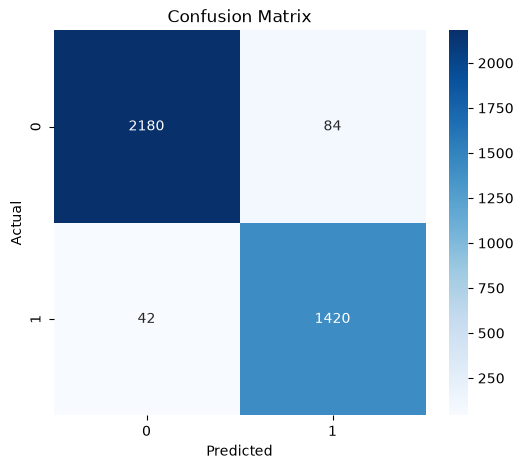

In [49]:
# ==========================================================
# Confusion Matrix
# ==========================================================

best_classifier = trained_models["Neural Network"]

predictions = best_classifier.predict(X_test_tfidf)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [47]:
# ==========================================================
# Classification Report
# ==========================================================

print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2264
           1       0.95      0.96      0.96      1462

    accuracy                           0.97      3726
   macro avg       0.96      0.96      0.96      3726
weighted avg       0.97      0.97      0.97      3726



In [ ]:
# ==========================================================
# Save Best Model
# ==========================================================

import joblib

joblib.dump(
    trained_models["Neural Network"],
    "../models/phishing_detector.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!
